# Исследование продаж компьютерных игр

В нашем распоряжении доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

<b> Цель исследования </b>
    
    1. Выявить характерный срок за который появляются новые и исчезают старые платформы
    2. Выбор потенциально прибыльных платформ
    3. Изучение влияния на продажи мнения критиков и пользователей
    4. Выбор потенциально прибыльных жанров
    5. Составление портрета пользователя по регионам
    
    
<b> Ход исследования </b>

Получим данные для исследования из файла /datasets/games.csv. Изучим какие данные имеются в исходной таблице - наличие пропусков, наименование столбцов, соответствие типа данных в столбцах.

На этапе подготовки данных обработаем пропуски, приведем в соответствие типы данных в столбцах, при необходимости переименуем столбцы и добавим новые. В ходе непосредственного исследования будем решать цели исследования.

План работы:
- обзор данных
- предобработка таблицы
- проведение анализа "срока жизни" платформ
- изучение лидирующих платформ 
- изучение игр по жанрам
- изучение влияния на продажи мнения критиков и пользователей
- составление портрета пользователей для купных регионов продаж
- общий вывод


## Изучение общей информации

Импортируем библиотеку pandas. Считаем данные из csv-файла в датафрейм и сохраним в переменную data.

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import plotly.express as px
import seaborn as sns

In [2]:
# чтение csv-файли и сохранение его в переменную data
try:
    data = pd.read_csv('C:/Users/evgen/Documents/data/Проекты по аналитике Яндекс/Данные для проектов/Комп.игры/games.csv')
except:
    data = pd.read_csv('/datasets/games.csv')

Выводим на экран первые 10 строк csv-файла

In [3]:
# вывод на экран первых 10 строк файла
data.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Изучим сводную информацию о таблице

In [4]:
# просмотр сводной информации о таблице
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
# сохраним изначальное количество строк и столбцов в переменной shape
shape = data.shape
# выведем значение переменной на экран
print(shape)

(16715, 11)


Из сводной информации видно, что в данных имеются пропуски, которые нужно изучить подробнее, заполнить их или удалить. В основном пропуски в столбцах с оценками критиков и пользователей, так же рейтинг установлен не на всех играх. Две строки с пропуском наименовании игры можно будет удалить. Тип данных в столбце с годом выпуска требуется привести к нужному виду int, тип данных в столбце с оценкой пользователей привести к типу float. Наименования столбцов не соответствуют "змеиному регистру".

Проверим наличие в таблице явных дубликатов

In [6]:
data.duplicated().sum()

0

### Вывод по общей информации

В таблице 16715 записей. В данных имеются пропуски в столбцах с оценками критиков и пользователей, так же рейтинг установлен не на всех играх. Тип данных в столбце с годом выпуска требуется привести к нужному виду int, а в столбце с оценкой пользователей привести к типу float. Явные дубликаты в таблице не обнаружены. Столбцы необходимо переименовать в соответствии со "змеиным регистром".

## Подготовка данных

### Переименование столбцов, изменение типа данных

Переименуем названия столбцов 

In [7]:
data.columns = data.columns.str.lower()

Изменим типы данных в столбце Год выпуска, так как год может быть только целым числом

In [8]:
# изменим тип данных в столбце year_of_release на int
data['year_of_release'] = data['year_of_release'].astype('Int64', errors='raise')

Тип данных в столбце с оценками пользователей - object, чтобы выяснить в чем причина выведем все уникальные значения этого столбца

In [9]:
# выведем все уникальные значения в столбце user_score
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

В данных встречается аббревиатура tbd. Согласно данным интернета она расшифровывается как «To Be Determined» (предстоит определить). Посчитаем сколько игр с таким значением оценки пользователей.

In [10]:
data.query("user_score == 'tbd'").shape

(2424, 11)

У достаточно большого количества игр оценка пользователей не определена - 14,5%. Заполнить такое большое количество данных средним или медианой нельзя - это может исказить результаты исследования. Заменим их на пустое значение типа NaN. И изменим тип данных в этом столбце на float.

In [11]:
data['user_score'] = data['user_score'].replace('tbd', np.nan).astype('float')

### Обработка пропусков

Посчитаем количество пропусков в столбцах

In [12]:
data.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Удалим строки с пропусками в названии и жанре игры.

In [13]:
data_games = data.dropna(subset = ['name', 'genre'])

Пропуски в годах выпуска скорее всего связаны с тем, что данные не были указаны изначально или удалились из-за технической ошибки. Пропусков в этом столбце всего 1,61% от общего количества данных. Предлагаю удалить строки с пропуском в годах выпуска.

In [14]:
data_games = data_games.dropna(subset = ['year_of_release'])

In [15]:
data_games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64

Достаточно большое количество строк в столбцах с оценками пользователей и критиков не заполнены. На это может быть несколько причин, например возможно что игры выпущенные давно в то время еще не оценивали пользователи, или новые игры еще не оценили.

Заполним пропуски в оценках на медианную оценку пользователей и критиков в играх разных жанров.

In [16]:
# перебираем каждый жанр в наборе уникальных значений столбца genre
for d in data_games['genre'].unique():
    # на каждом шаге цикла с помощью атрибута loc выбираем строки,
    # в которых в genre текущий жанр (d) и есть пропуски в user_score 
    data_games.loc[(data_games['genre'] == d) & (data_games['user_score'].isna()), 'user_score'] = \
    data_games.loc[(data_games['genre'] == d), 'user_score'].median()
    # и записываем в них медианное значение user_score среди строк с текущим жанром (d)

# проверяем, что все пропуски заполнены
print(data_games['user_score'].isna().sum())

0


In [17]:
# создаем группу данных data_games по полю genre
grp = data_games.groupby(['genre'])
# заменяем значения в столбце critic_score на медианные значения для каждой группы, определённой на первом шаге
data_games['critic_score'] = grp.critic_score.apply(lambda x: x.fillna(x.median()))

# проверяем, что все пропуски заполнены
print(data_games['critic_score'].isna().sum())

0


В столбце с рейтингом ESRB 6676 пропусков, это почти 40% от изначального количества строк. Пропуски в этом столбце могут быть связаны с тем, что рейтинг на новые игры еще не определен, или игра произведена в стране где данный рейтинг не проставляется. Предлагаю пропуски оставить без изменений.

Проверим таблицу на наличие неявных дубликатов

In [18]:
data_games.loc[data_games.duplicated(['name', 'platform', 'year_of_release'], keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


В таблице обнаружены неявные дубликаты, строки с игрой Madden NFL 13 выпущенной в 2012 году на платформе PS3 нужно объединить.

In [19]:
# сохраним данные о сумме продаж в Европе в переменной nfl
nfl = data_games[(data_games['name'] == 'Madden NFL 13') & (data_games['platform'] == 'PS3')]['eu_sales'].sum()

In [20]:
# удалим строку с дубликатом игры Madden NFL 13
data_games = data_games.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')

In [21]:
# перезапишем данные о продажах в Европе
data_games.loc[604, 'eu_sales'] = nfl

C:\Users\evgen\anaconda3\envs\ds_practicum_env\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [22]:
# выведем все строки с игрой Madden NFL 13
data_games.loc[data_games['name'] == 'Madden NFL 13']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
507,Madden NFL 13,X360,2012,Sports,2.53,0.15,0.0,0.17,81.0,5.8,E
604,Madden NFL 13,PS3,2012,Sports,2.11,0.23,0.0,0.23,83.0,5.5,E
3986,Madden NFL 13,Wii,2012,Sports,0.47,0.00,0.0,0.03,75.0,7.3,E
5887,Madden NFL 13,PSV,2012,Sports,0.28,0.00,0.0,0.02,63.0,7.3,E
7066,Madden NFL 13,WiiU,2012,Sports,0.21,0.00,0.0,0.02,75.0,6.7,E


### Добавление новых столбцов

Добавим новый столбец с суммой продаж по всем регионам

In [23]:
data_games['total_sales'] = data_games.loc[:, 'na_sales':'other_sales'].sum(axis = 1)

C:\Users\evgen\AppData\Local\Temp\ipykernel_3384\2516542343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_games['total_sales'] = data_games.loc[:, 'na_sales':'other_sales'].sum(axis = 1)


In [24]:
data_games.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,NaN,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,70.0,7.5,NaN,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,73.0,7.4,NaN,28.31


### Вывод подготовки данных

In [25]:
# сохраним количество строк и столбцов обновленной таблицы в переменной shape_2
shape_2 = data_games.shape
# выведем значение переменной на экран
print(shape_2)

(16443, 12)


In [26]:
# посчитаем сколько процентов данных от изначальных осталось для исследования
(shape_2[0]/shape[0]*100)

98.37271911456776

В ходе подготовки данных была проделана следующая работа:
- наименования столбцов приведены к нижнему регистру;
- изменены типы данных в столбцах: год выпуска, оценка пользователей;
- в столбце оценка пользователей значение 'tbd' заменено на пустое значение NaN;
- удалены строки с пропусками в столбцах с названием игры, жанром и годом выпуска;
- пропуски в оценках пользователей и критиков заполнены медианным значением в играх разных жанров;
- пропуски в столбце с рейтингом оставлены без изменений;
- добавлен новый столбец с суммой продаж по всем регионам;
- после обработки данных была удалена 271 строка, что составляет 1,62% от изначального количества.

Пропуски в данных могли возникнуть при переносе данных, если данные не были внесены изначально (например если рейтинг в стране выпуска есть свой или игра еще не оценена критиками и пользователями)

## Исследовательский анализ данных

### Изучение выпуска и продаж игр по году выпуска

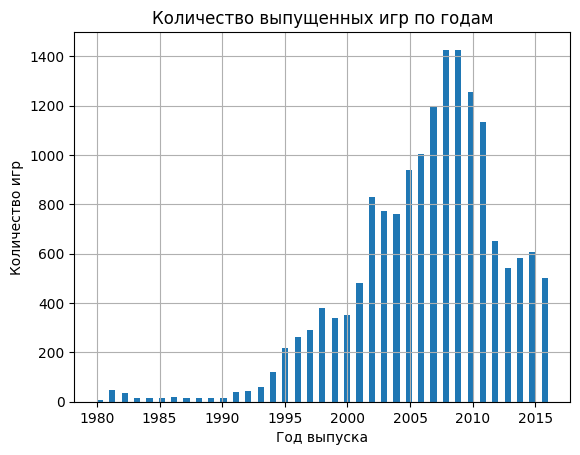

In [27]:
# построим гистограмму количества выпущенных игр по годам
data_games['year_of_release'].hist(bins=73, range=(1980, 2016))
plt.title('Количество выпущенных игр по годам')
plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.show()

Из графика видно, что основной рост количества выпускаемых игр начался с 2002 года (более 800 игр), максимум пришелся на 2008-2009 года (более 1400 игр в год), Минимально количество игр за год выпускалось до 1995 года (менее 200). Последние пять лет наблюдается спад.

Посмотрим как менялись продажи по платформам. 

In [28]:
data_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

Согласно таблице, в пятерку платформ с наибольшим количеством продаж входят PS2, X360, PS3, Wii, DS. Построим распределение продаж по годам.

In [29]:
# составим сводную таблицу продаж игр на разных платформах по годам
data_pivot = data_games.pivot_table(
    index='platform',
    columns='year_of_release',
    values='total_sales',
    aggfunc='sum'
)
data_pivot.head(10)

year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,
2600,11.38,35.68,28.88,5.84,0.27,0.45,0.67,1.94,0.74,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,63.20,51.36,56.57,43.76,27.78,15.14
DC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DS,NaN,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,...,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
GB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.43,64.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# добавим в сводную таблицу с суммой продаж по платформам за все года
data_pivot['total_sales'] = data_pivot.sum(axis=1)
data_pivot.sort_values(by='total_sales', ascending=False)

year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,total_sales
platform,,,,,,,,,,,,,,,,,,,,,
PS2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,53.90,26.40,5.64,0.45,NaN,NaN,NaN,NaN,NaN,1233.56
X360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135.26,120.29,170.03,143.84,99.74,88.58,34.74,11.96,1.52,961.24
PS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,118.52,130.93,142.17,156.78,107.36,113.25,47.76,16.82,3.60,931.34
Wii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,171.32,206.97,127.95,59.65,21.71,8.59,3.75,1.14,0.18,891.18
DS,NaN,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,...,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN,802.78
PS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,727.58
PS4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25.99,100.00,118.90,69.25,314.14
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,312.88
PSP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.55,37.78,35.04,17.82,7.69,3.14,0.24,0.12,NaN,289.53


Из 31 платформы, данные по которым есть в таблице суммарные продажи от 1233 у PS2 до 0,03. Для дальнейшего исследования возьмем данные по платформам суммарные продажи которых за все года более 250 млн.проданных копий. 

In [31]:
data_pivot = data_pivot[data_pivot['total_sales'] > 250.00]

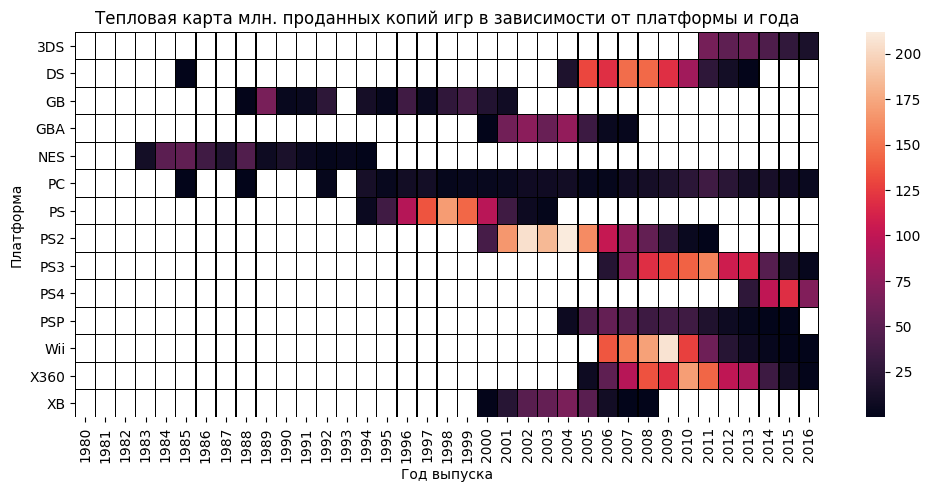

In [32]:
# Тепловая карта продаж игр в зависимости от платформы и года
plt.figure(figsize = (12,5))
ax = sns.heatmap(data_pivot.loc[:, 1980:2016], linewidths=.3, linecolor='black')
ax.set(
    title='Тепловая карта млн. проданных копий игр в зависимости от платформы и года', 
    ylabel='Платформа', 
    xlabel='Год выпуска'
);

Согласно графику новые платфортмы появляются и исчезают примерно за 10 лет. Дольше всех "продержалась" на рынке PC, но количество копий из года в год у нее не очень высокое. Максимальное количество продаж платформы достигают примерно на 5-6 год существования, потом это значение снижается. 

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Правильно, что используешь тепловую карту

Для прогноза продаж на 2017 год определим актуальный период в 5 лет: с 2012 по 2016 года. За этот период минимальное влияние на прогноз будут оказывать платформы которые уже исчезают, остануться только те, кто растет или достиг своего пика.

In [33]:
games = data_games[data_games['year_of_release'] > 2011]
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2885 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2885 non-null   object 
 1   platform         2885 non-null   object 
 2   year_of_release  2885 non-null   Int64  
 3   genre            2885 non-null   object 
 4   na_sales         2885 non-null   float64
 5   eu_sales         2885 non-null   float64
 6   jp_sales         2885 non-null   float64
 7   other_sales      2885 non-null   float64
 8   critic_score     2885 non-null   float64
 9   user_score       2885 non-null   float64
 10  rating           1610 non-null   object 
 11  total_sales      2885 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 295.8+ KB


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Для целей прогнозирования продаж на следующий год даже в традиционных бизнесах редко берут данные более чем за 2-3 года. А в такой динамично меняющейся индустрии, как компьютерные игры и вовсе не стоит брать слишком большой временной интервал - иначе обязательно захватишь уже отжившие тренды. Но и слишком короткий период тоже брать не стоит
</div>

<div class="alert alert-info"> 
<b> Комментарии студента: </b> 
    
    
Не совсем поняла - мне стоит исправить код и исследовать период в 2-3 года? Или просто взять на заметку что лучше сильно в прошлое не углубляться при планировании динамично развивающегося бизнеса?

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__

Всё хорошо, но в идеале взять данные за 13 и более года

In [34]:
games['platform'].nunique()

11

В таблице остались данные о 4022 играх, выпущенных с 2011 по 2016 года. За последние 6 лет только 12 платформ из 31 выпускали игры. Подробнее изучим данные по платформам за этот период.

In [35]:
games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64

Лидерами по продажам являются PS3 (445,57 млн.проданых копий), X360 (380,38 млн.проданых копий) и PS4 (314,14 млн.проданых копий). PS2 и PSP имеют минимальное количество продаж

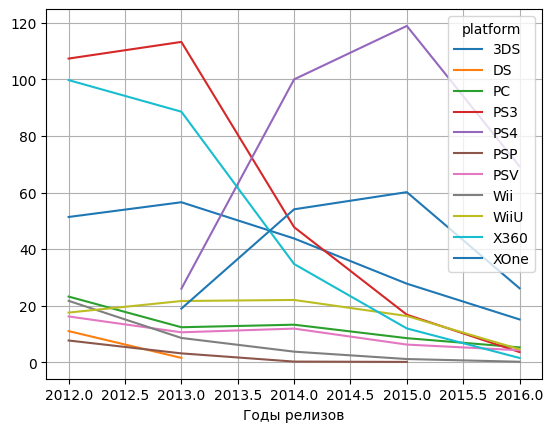

In [36]:
# построим график изменения объема продаж по платформам за последние 6 лет
games.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).plot(
    grid=True,
    xlabel='Годы релизов'
);

Согласно графику игры на некоторых платформах уже не выпукаются (PS2 с 2012 года, DS с 2014 года, PSP с 2016 года). Срок "жизни" платформ PS3, 3DS, Wii, X360 неумолимо заканчивается. Часть платформ не достигала продаж выше 25 млн.копий - PSV, WiiU. Не смотря на очевидную тягу к падению продаж у всех платформ, наиболее перспективно выглядят PS4, XOne. Так же возможной причиной снижения продаж является то, что данные за 2016 год могут быть не полными.

### Изучение выпуска и продаж игр по платформам

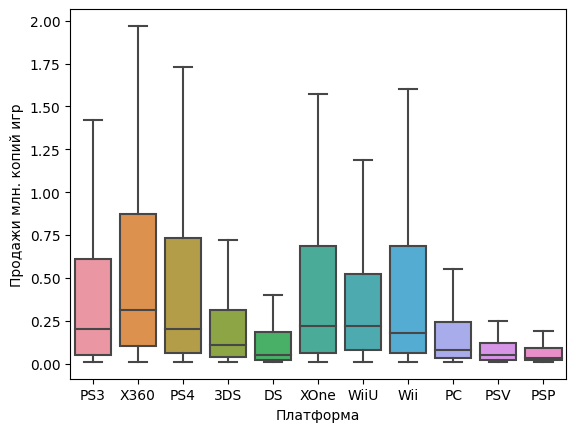

In [37]:
# построим график "ящик с усами"
sns.boxplot(x=games['platform'], y=games['total_sales'], showfliers=False)
plt.xlabel('Платформа')
plt.ylabel('Продажи млн. копий игр')
plt.show()

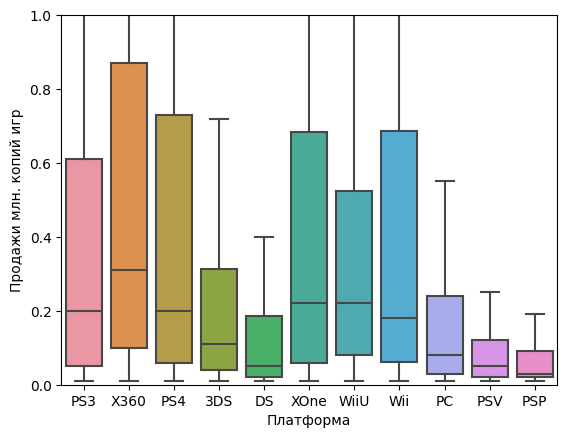

In [38]:
sns.boxplot(x=games['platform'], y=games['total_sales'], showfliers=False)
plt.ylim(0, 1)
plt.xlabel('Платформа')
plt.ylabel('Продажи млн. копий игр')
plt.show()

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

К сожалению, на этом графике видны только выбросы, и совсем не видны медиана и 75% квантиль. Для более обоснованных выводов нужно сделать дополнительный график, где будет отображена только нижняя часть boxplot-ов. Этого можно добиться, например, задав параметр ylim
</div>

<div class="alert alert-info"> 
<b> Комментарии студента: </b> 
    
    
Дополнительный график с ограничениями по оси y добавлен.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__

Учтено

За исследуемые 5 лет наиболее высокие третьи квартили имеют платформы X360, PS3, PS4 и XOne, все они примерно равны или больше 700 тыс. продаж копий игр одного релиза. Самая высокая медиана продаж у X360. Наиболее перспективные с точки зрения возможного начала жизненного цикла платформы PS4 и XOne входят в пятерку платформ с максимальным третьим квартилем и медианой продаж копий игр одного релиза.

Посмотрим как влияют на продажи отзывы пользователей и критиков на основе одной из наиболее перспективных платформ - PS4.

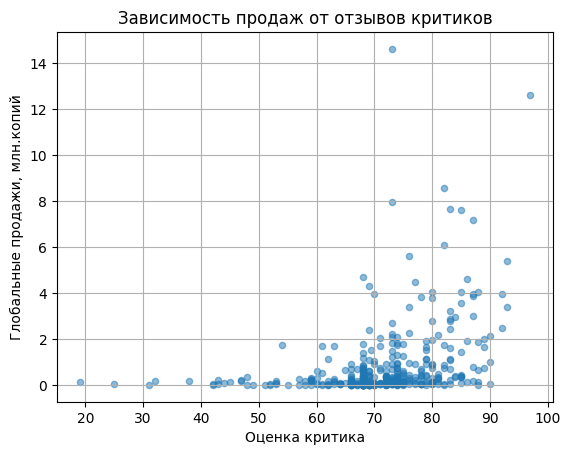

In [39]:
# построим диаграмму рассеяния для отзывов критиков
games[games['platform']=='PS4'].plot(x='critic_score', y='total_sales', kind='scatter', alpha=0.5, grid=True)
plt.title('Зависимость продаж от отзывов критиков')
plt.xlabel('Оценка критика')
plt.ylabel('Глобальные продажи, млн.копий')
plt.show()

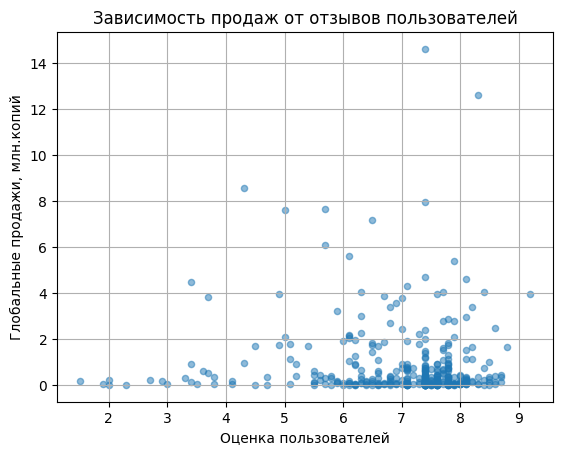

In [40]:
# построим диаграмму рассеяния для отзывов пользователей
games[games['platform']=='PS4'].plot(x='user_score', y='total_sales', kind='scatter', alpha=0.5, grid=True)
plt.title('Зависимость продаж от отзывов пользователей')
plt.xlabel('Оценка пользователей')
plt.ylabel('Глобальные продажи, млн.копий')
plt.show()

In [41]:
# посчитаем коэффициент корреляции между продажами и отзывами критиков
games[(games['platform'] == 'PS4')]['total_sales'].corr(games['critic_score'])

0.35147435925924925

In [42]:
# посчитаем коэффициент корреляции между продажами и отзывами пользователей
games[(games['platform'] == 'PS4')]['total_sales'].corr(games['user_score'])

-0.06548195077585682

Коэффициент корреляции между продажами и отзывами критиков положительный и равен 0,35. Это не достаточно высокий показатель чтобы говорить о прямой взаимосвязи, если зависимость и есть, то она не настолько прямая. Коэффициент корреляции между продажами и отзывами пользователей отрицательный и почти равен нулю - 0,06. Это значит что связи между отзывами пользователей и продажами нет. В целом оценка критиков больше влияет на продажи, чем оценка пользователей.

Построим диаграммы рассеивания по другим платформам.

In [43]:
platforms = games['platform'].unique()

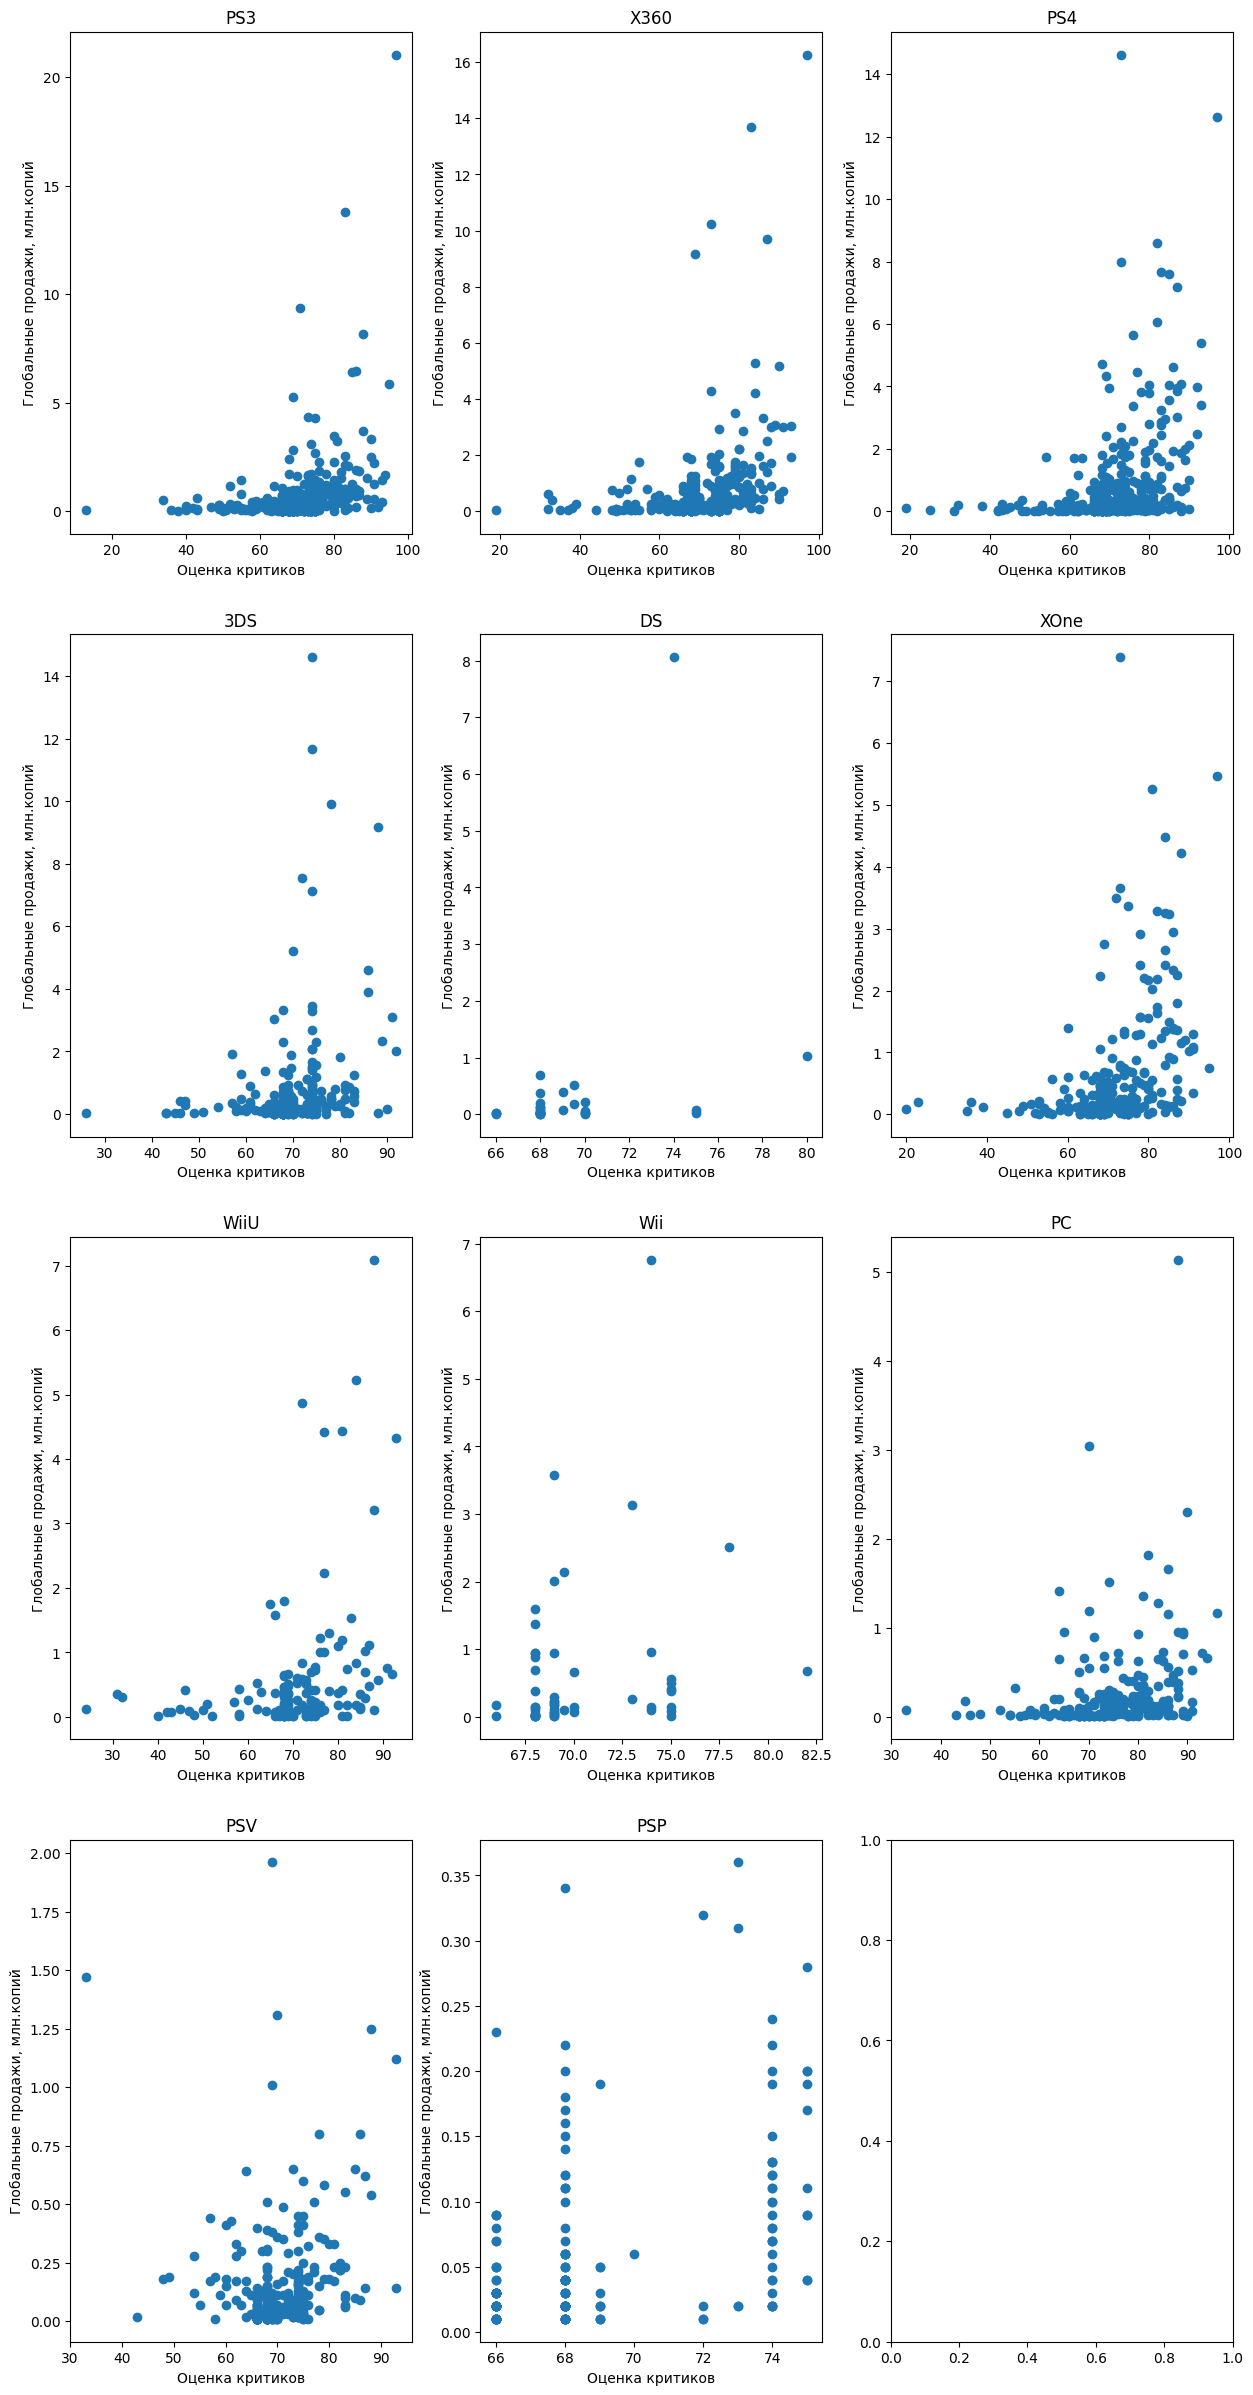

In [44]:
# построим диаграмму рассеяния для отзывов критиков
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 30))

for platform, ax in zip(platforms, axs.ravel()):
    # отфильтруем таблицу и построем график 
    cor_critic_score = games[(games['platform'] == platform)]['total_sales'].corr(games['critic_score'].astype('float32'))
    ax = ax    
    ax.scatter(games[games['platform']==platform].critic_score, games[games['platform']==platform].total_sales)    
    ax.set_title(platform)
    ax.set_xlabel('Оценка критиков')
    ax.set_ylabel('Глобальные продажи, млн.копий')
    ax.set
    
plt.show()

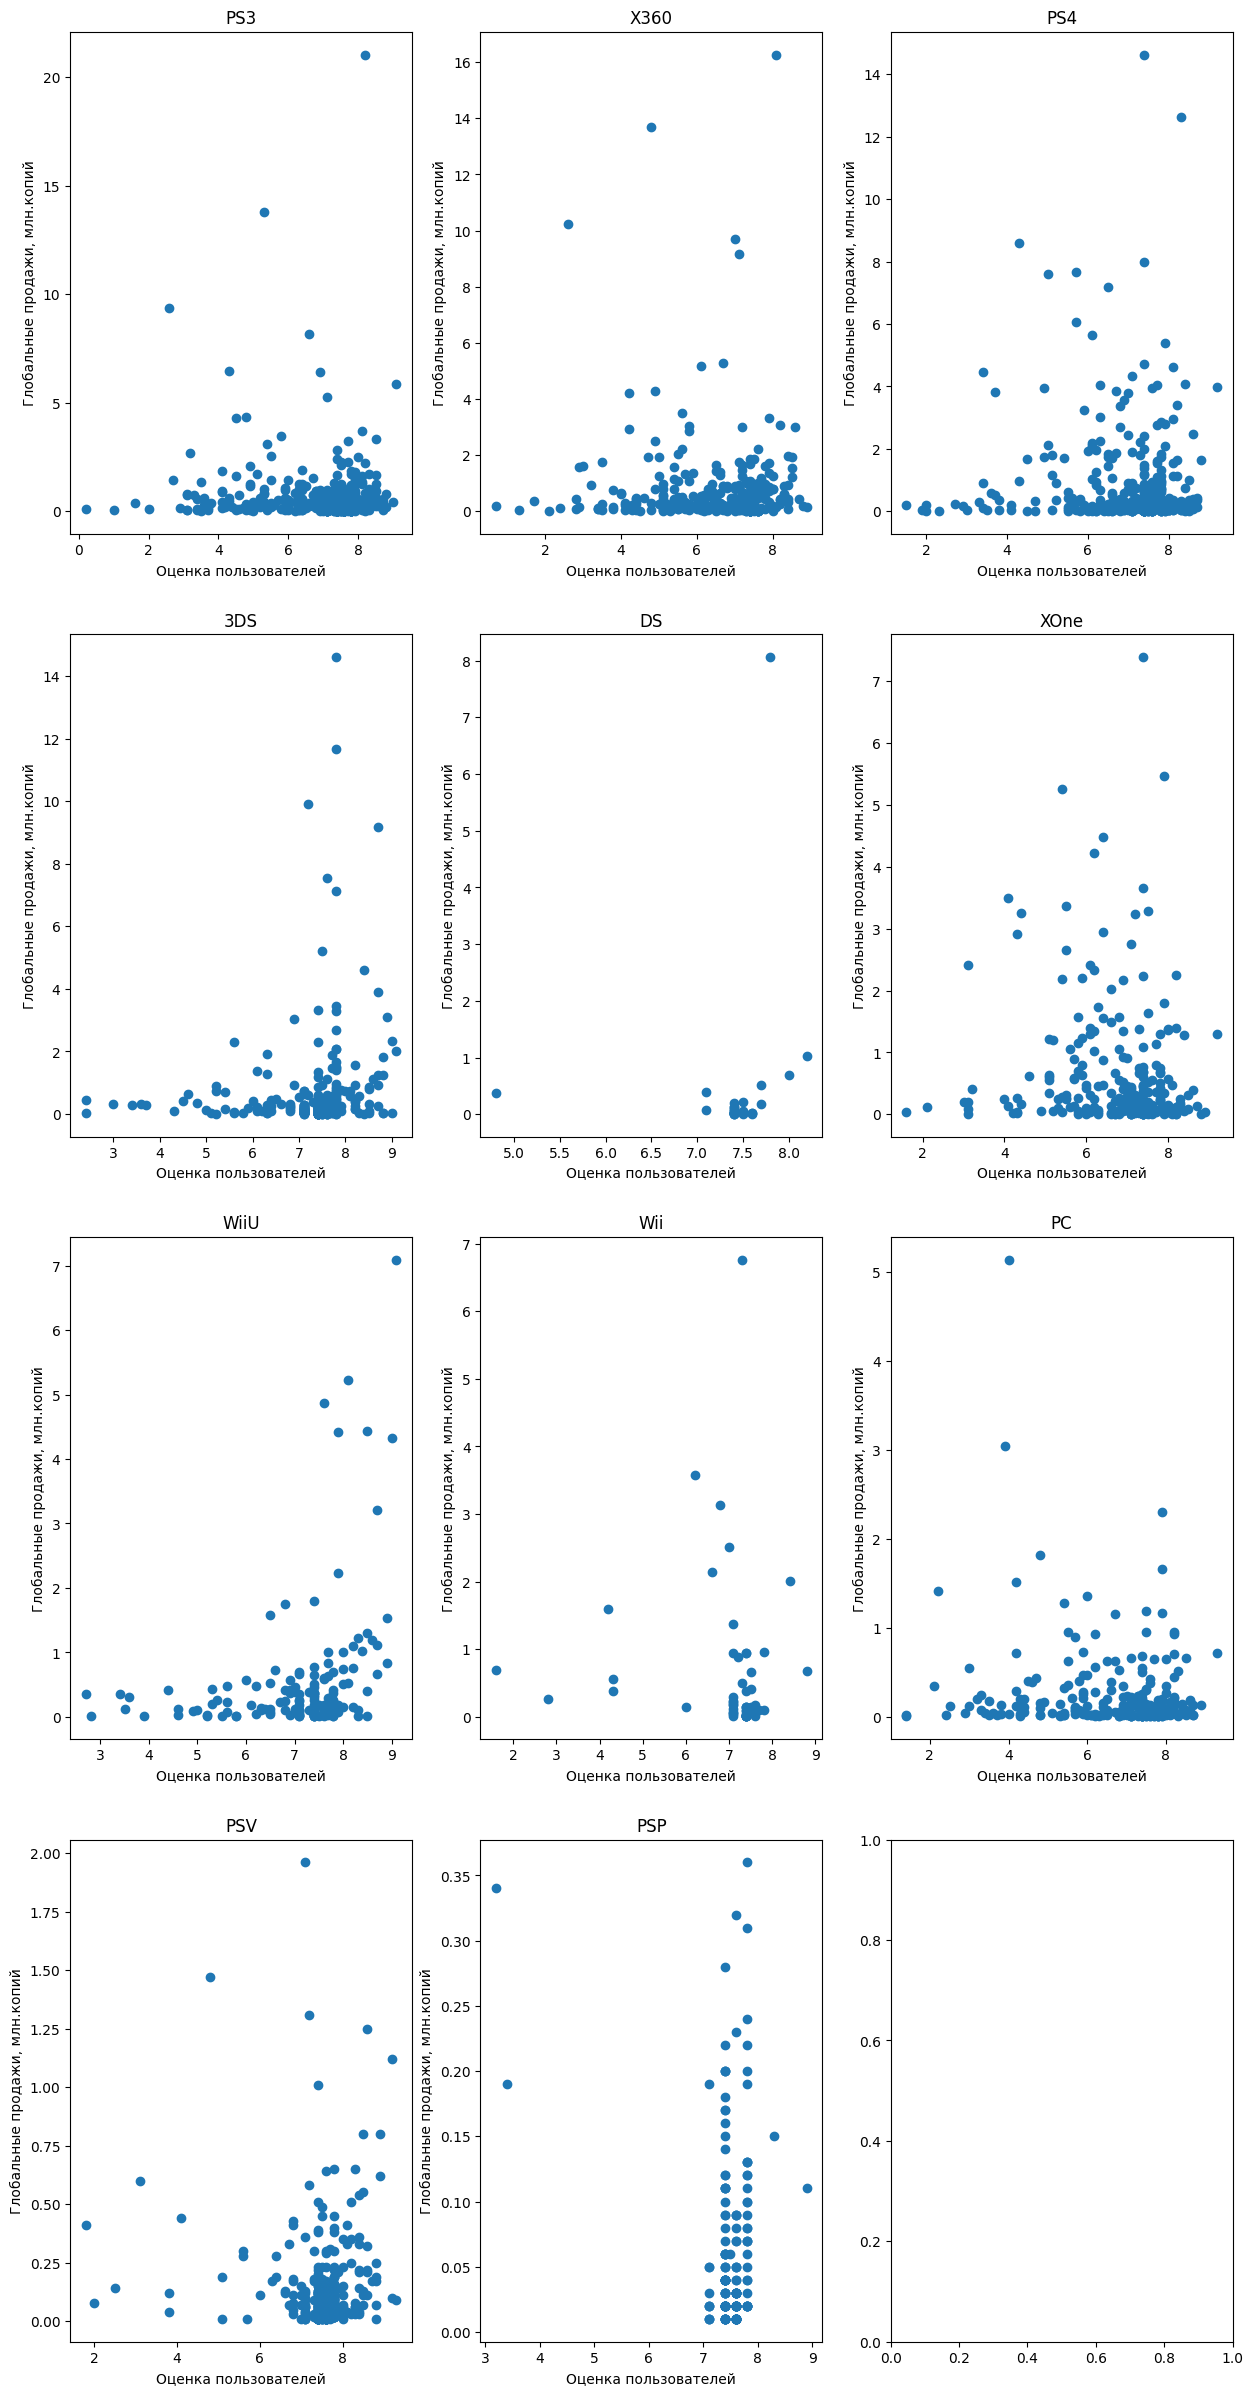

In [45]:
# построим диаграмму рассеяния для отзывов пользователей
fig, bxs = plt.subplots(nrows=4, ncols=3, figsize=(15, 30))

for platform, bx in zip(platforms, bxs.ravel()):
    # отфильтруем таблицу и построем график
    bx = bx
    bx.scatter(games[games['platform']==platform].user_score, games[games['platform']==platform].total_sales)
    bx.set_title(platform)
    bx.set_xlabel('Оценка пользователей')
    bx.set_ylabel('Глобальные продажи, млн.копий')
    bx.set
    
plt.show()

Посчитаем коэффициен корреляции между прродажами на популярных платформах и отзывами критиков и пользователей.

In [46]:
print('Коэффициент корреляции между продажами на PS3 и отзывами критиков: ', games[(games['platform'] == 'PS3')]['total_sales'].corr(games['critic_score']))
print('Коэффициент корреляции между продажами на PS3 и отзывами пользователей: ', games[(games['platform'] == 'PS3')]['total_sales'].corr(games['user_score']))
print()
print('Коэффициент корреляции между продажами на X360 и отзывами критиков: ', games[(games['platform'] == 'X360')]['total_sales'].corr(games['critic_score']))
print('Коэффициент корреляции между продажами на X360 и отзывами пользователей: ', games[(games['platform'] == 'X360')]['total_sales'].corr(games['user_score']))
print()
print('Коэффициент корреляции между продажами на 3DS и отзывами критиков: ', games[(games['platform'] == '3DS')]['total_sales'].corr(games['critic_score']))
print('Коэффициент корреляции между продажами на 3DS и отзывами пользователей: ', games[(games['platform'] == '3DS')]['total_sales'].corr(games['user_score']))
print()
print('Коэффициент корреляции между продажами на XOne и отзывами критиков: ', games[(games['platform'] == 'XOne')]['total_sales'].corr(games['critic_score']))
print('Коэффициент корреляции между продажами на XOne и отзывами пользователей: ', games[(games['platform'] == 'XOne')]['total_sales'].corr(games['user_score']))
print()
print('Коэффициент корреляции между продажами на PC и отзывами критиков: ', games[(games['platform'] == 'PC')]['total_sales'].corr(games['critic_score']))
print('Коэффициент корреляции между продажами на PC и отзывами пользователей: ', games[(games['platform'] == 'PC')]['total_sales'].corr(games['user_score']))

Коэффициент корреляции между продажами на PS3 и отзывами критиков:  0.3249691655668899
Коэффициент корреляции между продажами на PS3 и отзывами пользователей:  -0.08837014036914784

Коэффициент корреляции между продажами на X360 и отзывами критиков:  0.3337636738943918
Коэффициент корреляции между продажами на X360 и отзывами пользователей:  -0.03413344563451154

Коэффициент корреляции между продажами на 3DS и отзывами критиков:  0.2287680834843053
Коэффициент корреляции между продажами на 3DS и отзывами пользователей:  0.11157048404906766

Коэффициент корреляции между продажами на XOne и отзывами критиков:  0.3786165013085743
Коэффициент корреляции между продажами на XOne и отзывами пользователей:  -0.10515664470960717

Коэффициент корреляции между продажами на PC и отзывами критиков:  0.2585759196248832
Коэффициент корреляции между продажами на PC и отзывами пользователей:  -0.14767321932218552


Коэффициент корреляции между продажами и отзывами критиков по всем платформам положительный и находится в промежутке от 0,24 до 0,37. Значит что отзывы критиков если и влияют на продажи, то не достаточно сильно. Коэффициент корреляции между продажами и отзывами пользователей отрицательны и почти равны нулю. Это значит, что связи между отзывами пользователей и продажами нет. Оценка критиков больше влияет на продажи, чем оценка пользователей по всем платформам.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Графики отличные. Верная интерпритация значений корреляции Пирсона. Ты молодец =)
</div>

### Изучение выпуска и продаж игр по жанрам

Посмотрим на общее распределение игр по жанрам.

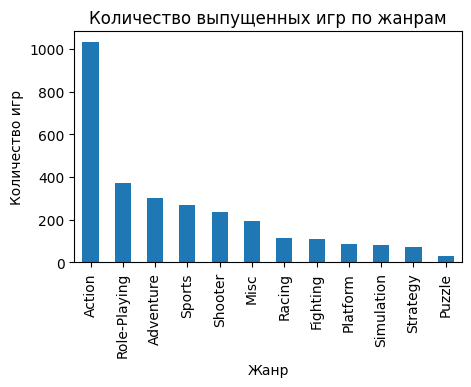

In [47]:
# Построим график распределение количества выпущенных игр по жанрам
genre_count = games['genre'].value_counts()
plt.figure(figsize=(5, 3))
genre_count.plot.bar()
plt.title('Количество выпущенных игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.show()

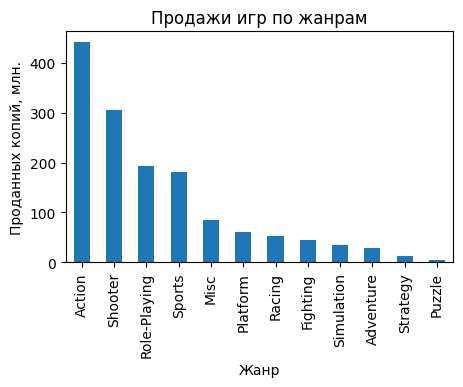

In [48]:
# Построим график суммы продаж игр разных жанров 
sales_by_genre = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
sales_by_genre.plot.bar()
plt.title('Продажи игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Проданных копий, млн.')
plt.show()

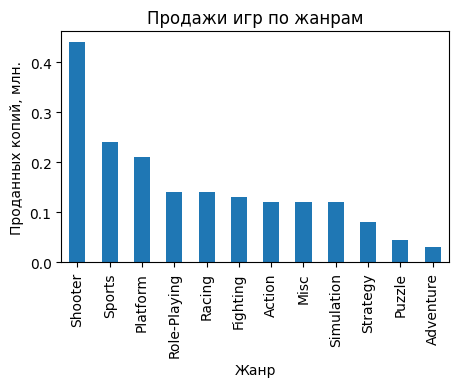

In [49]:
# Построим график медианных продаж игр разных жанров 
sales_by_genre = games.groupby('genre')['total_sales'].median().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
sales_by_genre.plot.bar()
plt.title('Продажи игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Проданных копий, млн.')
plt.show()

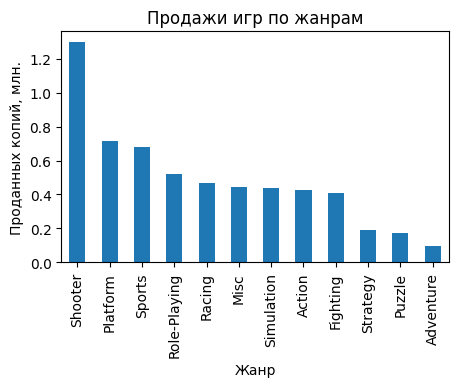

In [50]:
# Построим график средних продаж игр разных жанров 
sales_by_genre = games.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
sales_by_genre.plot.bar()
plt.title('Продажи игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Проданных копий, млн.')
plt.show()

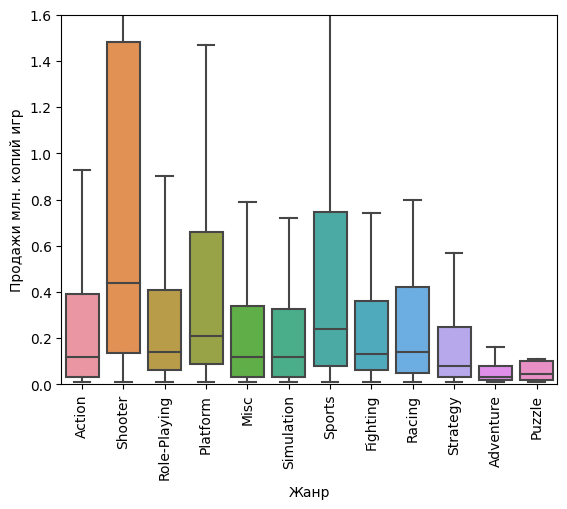

In [51]:
sns.boxplot(x=games['genre'], y=games['total_sales'], showfliers=False)
plt.ylim(0, 1.6)
plt.xlabel('Жанр')
plt.ylabel('Продажи млн. копий игр')
plt.xticks(rotation=90)
plt.show()

Больше всего игр выпускалось в жанрах 'Action', 'Role-Playing', 'Adventure', Sports', 'Misc'. Больше всего копий игр продано в жанрах 'Action', 'Shooter', 'Role-Playing', 'Sports'. Среди медианных и средних продаж лидируют Shooter, Sports, Platform, Role-Playing, Racing. Согласно графику, медиана продаж самая высокая у Шутеров (более 400 тыс.копий), далее идут Спорт и Платформы (200-300 тыс.копий). Медианы остальных жанров не дотягивают и до 200 тыс.проданных копий. Самыми прибыльными и перспективными являются игры в жанрах Shooter, Sports, Platform.

### Вывод по исследовательскому анализу данных

За период с 2002 по 2019 год количество выпускаемых игр активно росло, достигнув максимума в 2008-2009 годах. С 2015 года наблюдается спад. В пятерку платформ с наибольшим количеством продаж входят PS2, X360, PS3, Wii, DS. На рынке постоянно появляются и исчезают новые платформы, но дольше всех продержалась PC. Максимальное количество продаж игры на любой платформе достигает примерно на 5-6 год существования, потом это значение снижается.
Для прогноза продаж на 2017 год выбран актуальный период в 6 лет: с 2011 по 2016 года. В этот период лидерами по продажам являются PS3, X360 и PS4. Срок «жизни» платформ PS3, 3DS, Wii, X360 неумолимо заканчивается. Несмотря на падение продаж, наиболее перспективно выглядят PS4 и XOne. Возможной причиной снижения продаж может быть то, что данные за 2016 год могут быть неполными.
За исследуемые 6 лет наиболее высокие результаты имеют платформы X360, PS3, PS4 и XOne. Самая высокая медиана продаж у X360. Наиболее перспективные с точки зрения возможного начала жизненного цикла платформы PS4 и Xbox One входят в пятерку платформ с максимальным третьим квартилем и медианой продаж копий игр одного релиза.
Отзывы критиков не достаточно сильно влияют на продажи. Связи между отзывами пользователей и продажами нет. Оценка критиков больше влияет на продажи, чем оценка пользователей по всем платформам.
Больше всего игр выпускалось в жанрах 'Action', 'Role-Playing', 'Adventure'. Больше всего копий игр продано в жанрах 'Action', 'Shooter', 'Role-Playing'. Среди медианных и средних продаж лидируют Shooter, Sports, Platform. Самыми прибыльными и перспективными являются игры в жанрах Shooter, Sports, Platform.

## Составление портрета пользователей по регионам

Найдем какие платформы популярны в каждом из регионов.

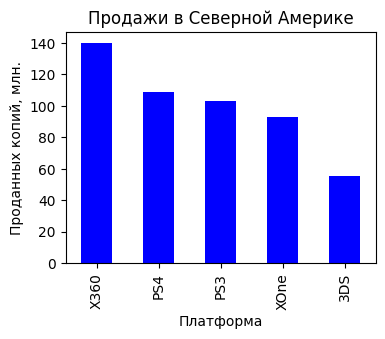

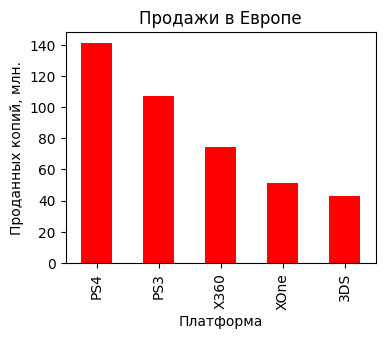

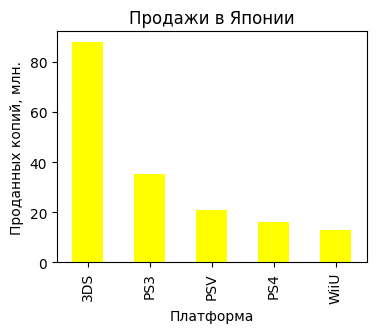

In [52]:
# построим гистограмму с распределением продаж игр по платформам в Северной Америке
plt.figure(figsize=(4, 3))
sales_by_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
sales_by_na.plot.bar(color='blue')
plt.title('Продажи в Северной Америке')
plt.xlabel('Платформа')
plt.ylabel('Проданных копий, млн.')
plt.show()

# построим гистограмму с распределением продаж игр по платформам в Европе
plt.figure(figsize=(4, 3))
sales_by_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
sales_by_eu.plot.bar(color='red')
plt.title('Продажи в Европе')
plt.xlabel('Платформа')
plt.ylabel('Проданных копий, млн.')
plt.show()

# построим гистограмму с распределением продаж игр по платформам в Японии
plt.figure(figsize=(4, 3))
sales_by_jp = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
sales_by_jp.plot.bar(color='yellow')
plt.title('Продажи в Японии')
plt.xlabel('Платформа')
plt.ylabel('Проданных копий, млн.')
plt.show()

Наиболее популярные платформы в Северной Америке X360, PS3, PS4, XOne, 3DS. Наиболее популярные платформы в Европе PS3, PS4, X360, 3DS, PS. 
Наиболее популярные платформы в Японии 3DS, PS3, PSP, PSV, PS4. Популярные платформы в Северной Америке и Европе почти совпадают, отличается только доля каждой платформы в регионе. Рынок Японии отличается своей оригинальностью - там пользуются популярностью платформы, которые не популярны в других регионах. Например 3DS несомненный лидер на японском рынке, а в Северной Америке и Европе не входит и в тройку лидеров.

In [53]:
# выведем топ-5 жанров популярных в Северной Америке
games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

In [54]:
# выведем топ-5 жанров популярных в Европе
games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

In [55]:
# выведем топ-5 жанров популярных в Японии
games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64

В Северной Америке и Европе популярны почти одинаковые жанры игр: Экшены, Шутеры, Спорт, Ролевые игры, Гонки. Рынок Японии отличается и популярными жанрами: Ролевые игры и Экшены имеют большую часть продаж, далее за ним идут Бои и Платформы.

Изучим продажи в регионах по рейтингу ESRB

In [56]:
data_games_pivot = games.pivot_table(
    index='rating',
    values=['na_sales', 'eu_sales', 'jp_sales'],
    aggfunc='sum'
)
data_games_pivot

,eu_sales,jp_sales,na_sales
rating,,,
E,113.03,28.33,114.37
E10+,55.37,8.19,75.70
M,193.96,21.20,231.57
T,52.96,26.02,66.02


<Figure size 1500x500 with 0 Axes>

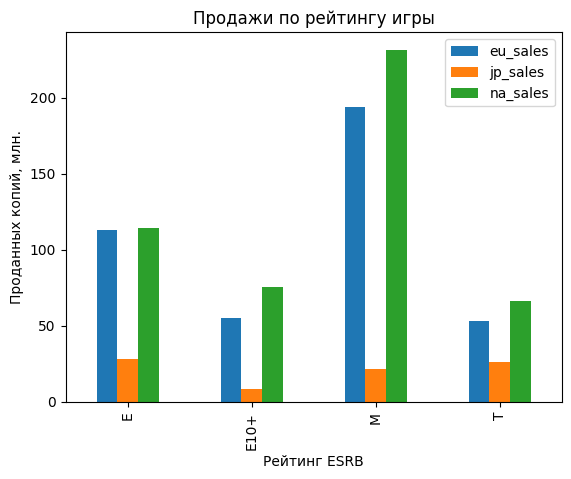

In [57]:
plt.figure(figsize=(15, 5))
data_games_pivot.plot.bar()
plt.title('Продажи по рейтингу игры')
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Проданных копий, млн.')
plt.show()

EC — для детей младшего возраста;
E — для всех возрастных категорий;
E 10+ — для лиц старше 10 лет;
T — для лиц старше 13 лет;
M — для лиц старше 17 лет;
AO — для взрослых старше 18 лет.

В Европе и Северной Америке наибольшее количество продаж у игр с рейтингом М, далее идут игры Е, Е10+ и Т. В Японии чаще покупают игры с рейтингом Е и Т, но количество продаж значительно ниже в сравнении с другими регионами. Возможно это связано с тем, что в Японии с 2002 года имеется свой рейтинг игр CERO.

### Вывод о пользователях каждого региона

Типичный покупатель игр в Северной Америке предпочитает играть в игры жанра Экшн и Шутер с рейтингом "старше 17 лет", на платформах X360, PS3, PS4. В Европе большинство покупателей играют в Экшены и Шутеры с рейтингом "старше 17 лет" на платформах PS3, PS4, X360. Большинство игроков в Японии предпочитают платформы 3DS, PS3, PSP; среди игр в Японии выделяются Ролевые игры и Экшен, с рейтингом "для всех возрастных категорий".

## Общий вывод

В ходе работы были изучены и обработаны данные о продажах игр за 1980-2016 года. 


На первом этапе изучена общая информация. В таблице 16715 записей. В данных имеются пропуски, тип данных указан не верно. Явные дубликаты в таблице не обнаружены. Столбцы необходимо переименовать в соответствии со "змеиным регистром".


В ходе подготовки данных:
- наименования столбцов приведены к нижнему регистру;
- изменены типы данных в столбцах: год выпуска, оценка пользователей;
- в столбце оценка пользователей значение 'tbd' заменено на пустое значение NaN;
- удалены строки с пропусками в столбцах с названием игры, жанром и годом выпуска;
- пропуски в оценках пользователей и критиков заполнены медианным значением в играх разных жанров;
- пропуски в столбце с рейтингом оставлены без изменений;
- добавлен новый столбец с суммой продаж по всем регионам.


После обработки данных была удалена 271 строка, что составляет 1,62% от изначального количества.


За период с 2002 по 2019 год количество выпускаемых игр активно росло, достигнув максимума в 2008-2009 годах. С 2015 года наблюдается спад. В пятерку платформ с наибольшим количеством продаж входят PS2, X360, PS3, Wii, DS. На рынке постоянно появляются и исчезают новые платформы, но дольше всех продержалась PC. Максимальное количество продаж игры на любой платформе достигает примерно на 5-6 год существования, потом это значение снижается.
Для прогноза продаж на 2017 год выбран актуальный период в 6 лет: с 2011 по 2016 года. В этот период лидерами по продажам являются PS3, X360 и PS4. Срок «жизни» платформ PS3, 3DS, Wii, X360 неумолимо заканчивается. Несмотря на падение продаж, наиболее перспективно выглядят PS4 и XOne. Возможной причиной снижения продаж может быть то, что данные за 2016 год могут быть неполными.
За исследуемые 6 лет наиболее высокие результаты имеют платформы X360, PS3, PS4 и XOne. Самая высокая медиана продаж у X360. Наиболее перспективные с точки зрения возможного начала жизненного цикла платформы PS4 и Xbox One входят в пятерку платформ с максимальным третьим квартилем и медианой продаж копий игр одного релиза.
Отзывы критиков не достаточно сильно влияют на продажи. Связи между отзывами пользователей и продажами нет. Оценка критиков больше влияет на продажи, чем оценка пользователей по всем платформам.
Больше всего игр выпускалось в жанрах Action, Role-Playing, Adventure. Больше всего копий игр продано в жанрах Action, Shooter, Role-Playing. Среди медианных и средних продаж лидируют Shooter, Sports, Platform. Самыми прибыльными и перспективными являются игры в жанрах Shooter, Sports, Platform.

Типичный покупатель игр в Северной Америке предпочитает играть в игры жанра Экшн и Шутер с рейтингом "старше 17 лет", на платформах X360, PS3, PS4. В Европе большинство покупателей играют в Экшены и Шутеры с рейтингом "старше 17 лет" на платформах PS3, PS4, X360. Большинство игроков в Японии предпочитают платформы 3DS, PS3, PSP; среди игр в Японии выделяются Ролевые игры и Экшен, с рейтингом "для всех возрастных категорий".

-------
Предлагается в рекламной кампании на следующий год уделить особое внимание играм на платформах PS4, XOne и 3DS, в жанрах Шутер и Экшн для Европы и Северной Америки, а для Японии в жанрах Экшн и Ролевые игры. В основом большинство игр рассчитано на игроков, которым 17 лет и старше, основное внимание можно уделить им. 